## 1. Data Collection and Importing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/spam.csv"
df = pd.read_csv(path, encoding="latin-1")
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
print("Size-",df.size)
print("Shape-",df.shape)

Size- 27860
Shape- (5572, 5)


## 2. Data Cleaning

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None


In [ ]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
display(df.head())

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
target,0
text,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [ ]:
df['target'] = encoder.fit_transform(df['target'])
display(df.head())

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. Exploratorary Data Analysis


In [ ]:
display(df.head())

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


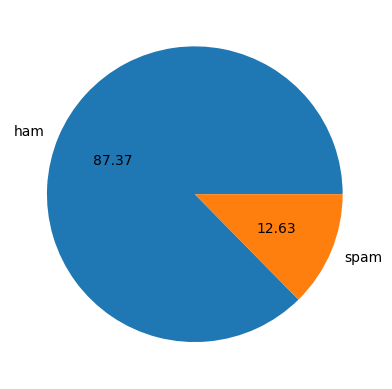

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [ ]:
import nltk
!pip install nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df['number_char'] = df['text'].apply(len)
df.head()

,target,text,number_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
import nltk
!pip install nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['number_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,number_char,number_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df['number_sent'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,number_char,number_words,number_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['number_char', 'number_words', 'number_sent']].describe()

,number_char,number_words,number_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 0][['number_char', 'number_words', 'number_sent']].describe()

,number_char,number_words,number_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 1][['number_char', 'number_words', 'number_sent']].describe()

,number_char,number_words,number_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


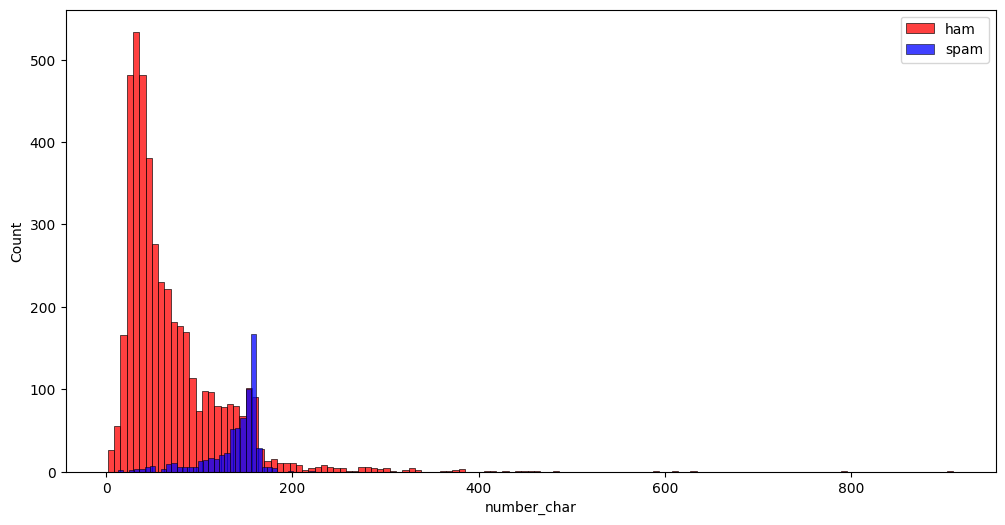

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['number_char'], color = 'red', label = 'ham')
sns.histplot(df[df['target'] == 1]['number_char'], color = 'blue', label = 'spam')
plt.legend()
plt.show()

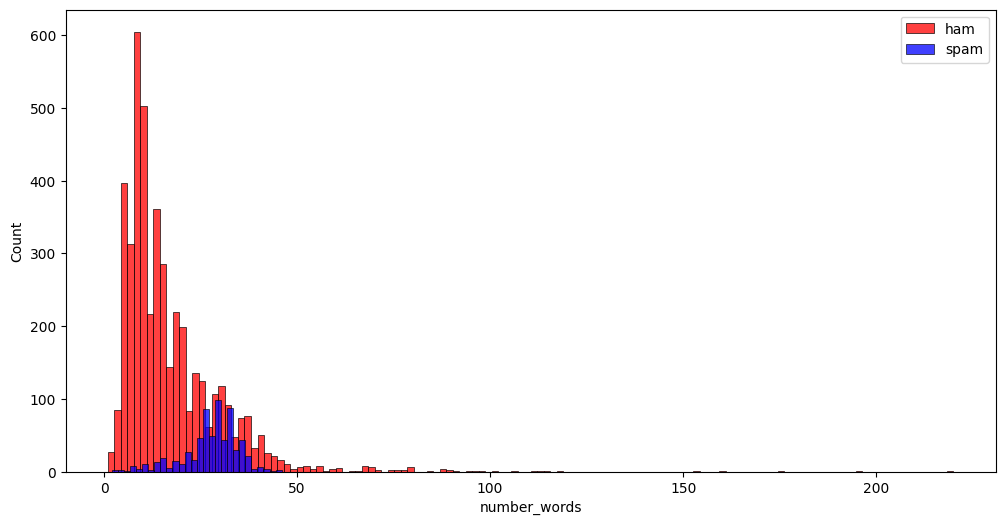

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['number_words'], color = 'red', label = 'ham')
sns.histplot(df[df['target'] == 1]['number_words'], color = 'blue', label = 'spam')
plt.legend()
plt.show()

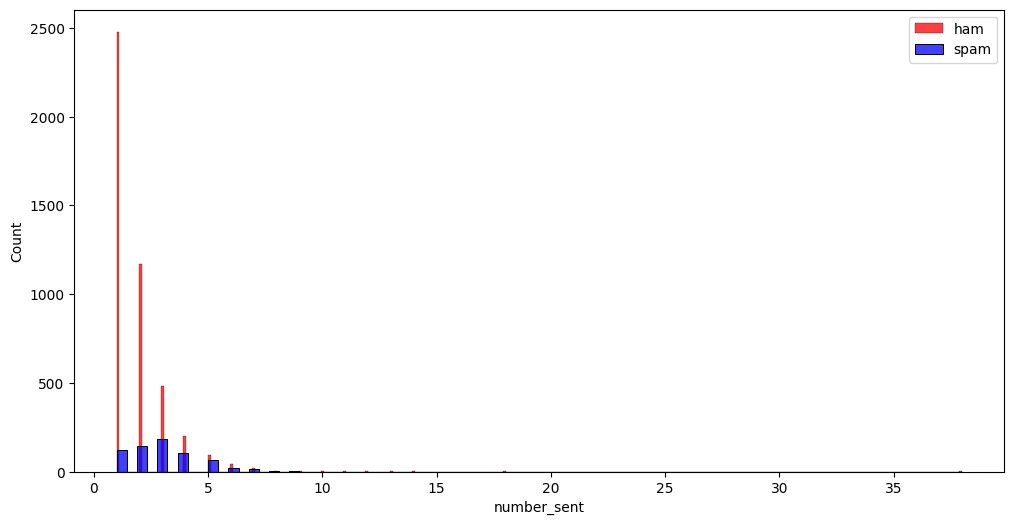

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['number_sent'], color = 'red', label = 'ham')
sns.histplot(df[df['target'] == 1]['number_sent'], color = 'blue', label = 'spam')
plt.legend()
plt.show()

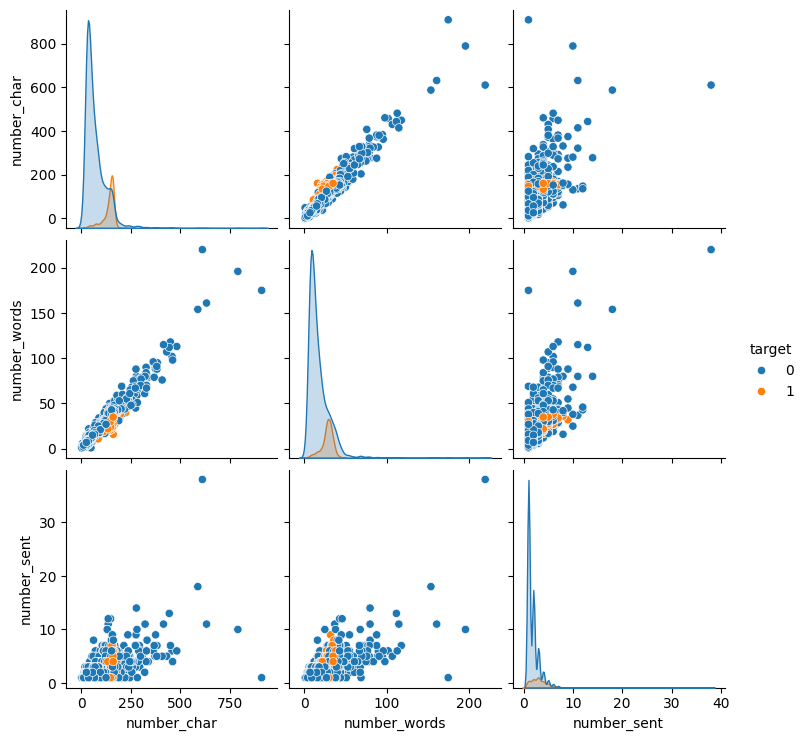

In [ ]:
sns.pairplot(df,hue='target')
plt.show()

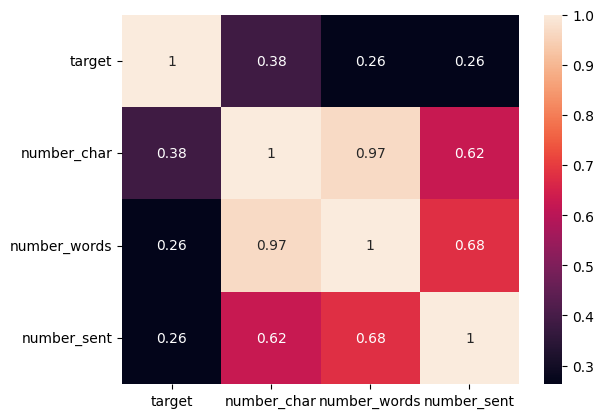

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

## 4. Data Processing

In [ ]:
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import string

lemmatizer = WordNetLemmatizer()

In [ ]:
def get_wordnet_pos(word):
  tag = pos_tag([word])[0][1][0].upper()
  tag_dict = {"J":wordnet.ADJ,
              "N":wordnet.NOUN,
              "V":wordnet.VERB,
              "R":wordnet.ADV}
  return tag_dict.get(tag,wordnet.NOUN)

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()
  for i in text:
    y.append(lemmatizer.lemmatize(i,get_wordnet_pos(i)))

  return " ".join(y)

In [ ]:
text = "The students were studying hard for their final exams, but many complained that the assignments were too difficult, exhausting, and unnecessary at times."
print(transform_text(text))


student study hard final exam many complain assignment difficult exhaust unnecessary time


In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,number_char,number_words,number_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf life around though


In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='black')

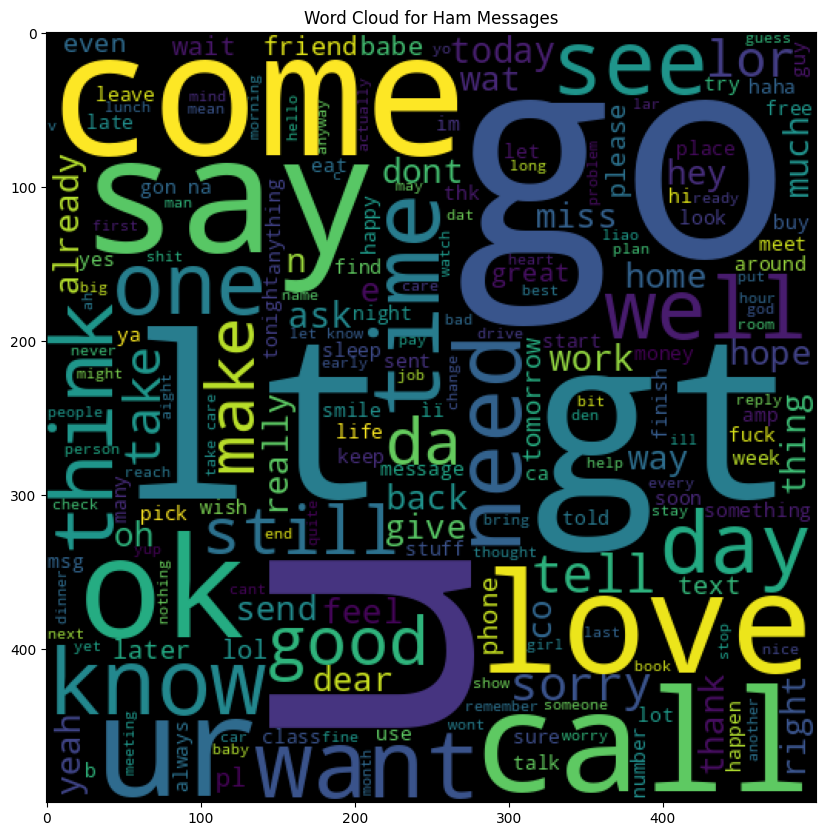

In [ ]:
wc_ham = wc.generate(df[df['target'] == 0] ['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,10))
plt.title("Word Cloud for Ham Messages")
plt.imshow(wc_ham)

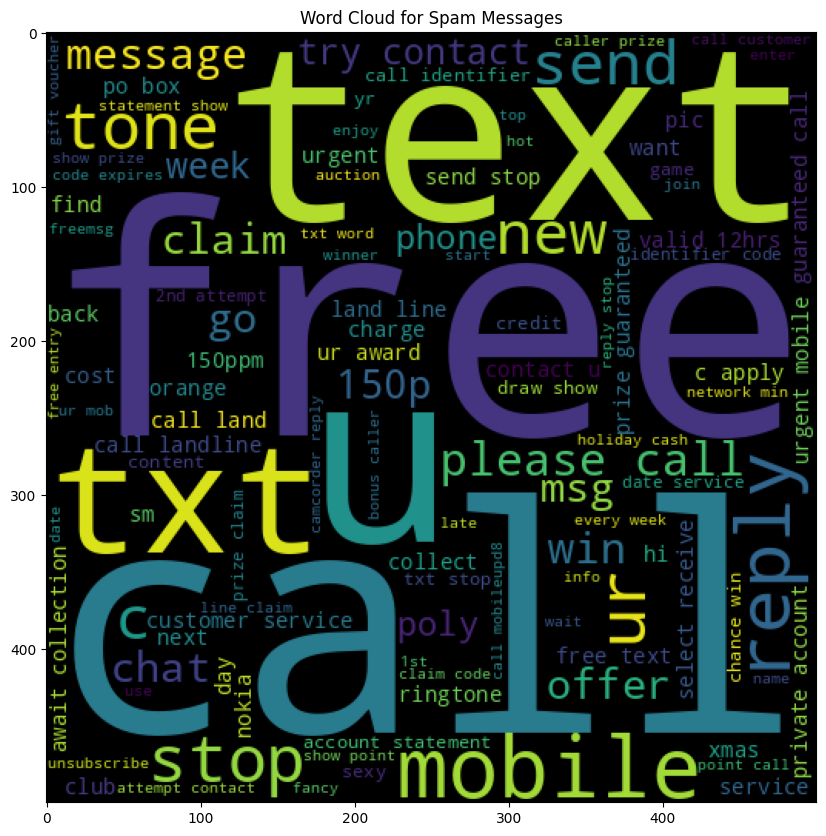

In [ ]:
wc_spam = wc.generate(df[df['target'] == 1] ['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,10))
plt.title("Word Cloud for Spam Messages")
plt.imshow(wc_spam)

In [ ]:
ham_corpus = []
for i in df[df['target'] == 0]['transformed_text'].tolist():
  for j in i.split():
    ham_corpus.append(j)

In [ ]:
len(ham_corpus)

35404

        0    1
0       u  935
1     get  586
2      go  494
3    come  298
4      gt  288
5      lt  287
6       2  284
7    know  237
8    call  233
9    like  231
10     ok  217
11   time  213
12   good  213
13   want  208
14   love  204
15    say  203
16     ur  197
17    day  190
18   need  170
19    one  165
20   take  164
21    see  160
22    lor  159
23      4  156
24   make  153
25   home  152
26   well  150
27  think  148
28  still  143
29     da  142


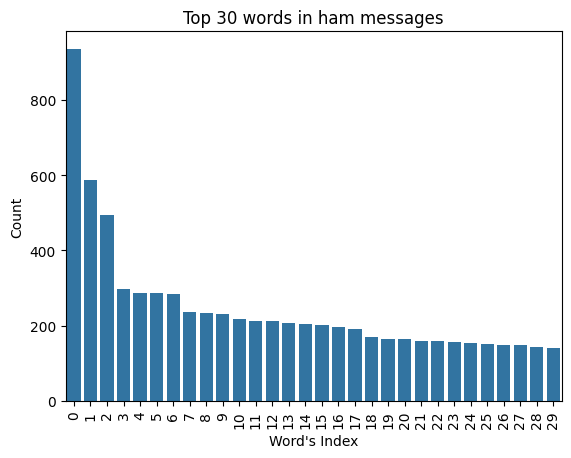

In [ ]:
import pandas as pd
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
print(pd.DataFrame(Counter(ham_corpus).most_common(30)))
plt.title("Top 30 words in ham messages")
plt.xticks(rotation=90)
plt.xlabel("Word's Index")
plt.ylabel("Count")
plt.show()

In [ ]:
spam_cospus = []
for i in df[df['target'] == 1]['transformed_text'].tolist():
  for j in i.split():
    spam_cospus.append(j)

In [ ]:
len(spam_cospus)

9939

           0    1
0       call  320
1       free  191
2          2  155
3        txt  130
4          u  126
5       text  121
6         ur  119
7     mobile  114
8       stop  104
9      reply  103
10     claim   98
11         4   97
12     prize   82
13         c   80
14       get   80
15       new   67
16   service   64
17      tone   63
18      send   60
19    urgent   57
20   contact   56
21     award   55
22     nokia   54
23     phone   52
24      cash   51
25       win   49
26      week   49
27    please   49
28       min   45
29  customer   42


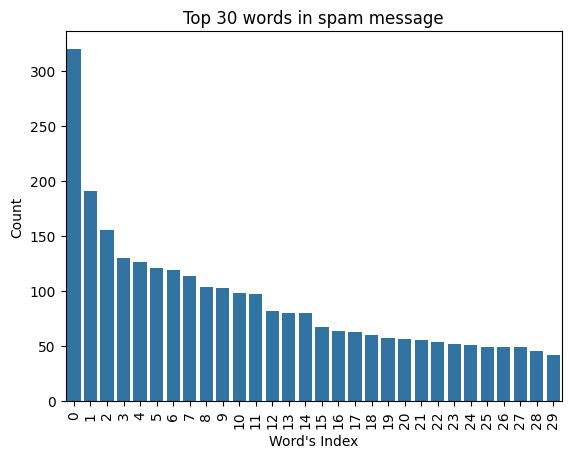

In [ ]:
import numpy as np
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_cospus).most_common(30))[1])
print(pd.DataFrame(Counter(spam_cospus).most_common(30)))
plt.title("Top 30 words in spam message")
plt.xticks(rotation=90)
plt.xlabel("Word's Index")
plt.ylabel("Count")
plt.show()

## 5. Model Training

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [ ]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#x = scaler.fit_transform(x)

In [ ]:
x.shape

(5169, 3000)

In [ ]:
display(x)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
y = df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)

In [ ]:
print("Accuracy-\n", accuracy_score(y_test,y_pred1))
print("\nConfusion Matrix-\n", confusion_matrix(y_test,y_pred1))
print("\nPrecision-\n", precision_score(y_test,y_pred1))

Accuracy-
 0.8694390715667312

Confusion Matrix-
 [[784 112]
 [ 23 115]]

Precision-
 0.5066079295154186


In [ ]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)

In [ ]:
print("Accuracy-\n", accuracy_score(y_test,y_pred2))
print("\nConfusion Matrix-\n", confusion_matrix(y_test,y_pred2))
print("\nPrecision-\n", precision_score(y_test,y_pred2))

Accuracy-
 0.9729206963249516

Confusion Matrix-
 [[896   0]
 [ 28 110]]

Precision-
 1.0


In [ ]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)

In [ ]:
print("Accuracy-\n", accuracy_score(y_test,y_pred3))
print("\nConfusion Matrix-\n", confusion_matrix(y_test,y_pred3))
print("\nPrecision-\n", precision_score(y_test,y_pred3))

Accuracy-
 0.9835589941972921

Confusion Matrix-
 [[895   1]
 [ 16 122]]

Precision-
 0.991869918699187


## 6. Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [ ]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [ ]:
accuracy_scores = []
precision_scores = []

In [ ]:
for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9042553191489362
Precision -  1.0
For  NB
Accuracy -  0.9729206963249516
Precision -  1.0
For  DT
Accuracy -  0.9313346228239845
Precision -  0.845360824742268
For  LR
Accuracy -  0.9535783365570599
Precision -  0.96875
For  RF
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8518518518518519
For  BgC
Accuracy -  0.9555125725338491
Precision -  0.859375
For  ETC
Accuracy -  0.9787234042553191
Precision -  0.9833333333333333
For  GBDT
Accuracy -  0.9487427466150871
Precision -  0.9381443298969072
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9338842975206612


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=True)

In [ ]:
performance_df

,Algorithm,Accuracy,Precision
3,DT,0.931335,0.845361
6,AdaBoost,0.921663,0.851852
7,BgC,0.955513,0.859375
10,xgb,0.968085,0.933884
9,GBDT,0.948743,0.938144
4,LR,0.953578,0.968750
5,RF,0.972921,0.974138
0,SVC,0.975822,0.974790
8,ETC,0.978723,0.983333
2,NB,0.972921,1.000000


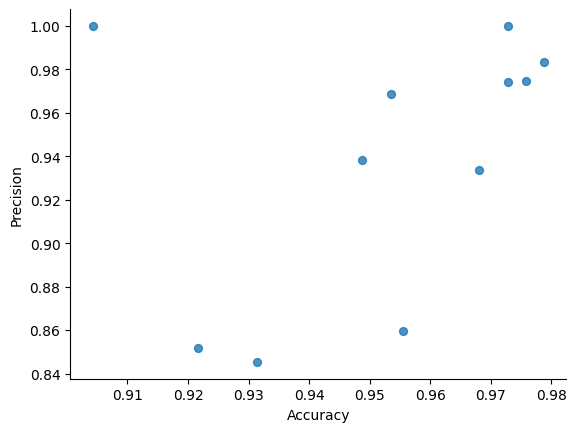

In [ ]:
from matplotlib import pyplot as plt
performance_df.plot(kind='scatter', x='Accuracy', y='Precision', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [ ]:
performance_df1

,Algorithm,variable,value
0,DT,Accuracy,0.931335
1,AdaBoost,Accuracy,0.921663
2,BgC,Accuracy,0.955513
3,xgb,Accuracy,0.968085
4,GBDT,Accuracy,0.948743
5,LR,Accuracy,0.953578
6,RF,Accuracy,0.972921
7,SVC,Accuracy,0.975822
8,ETC,Accuracy,0.978723
9,NB,Accuracy,0.972921


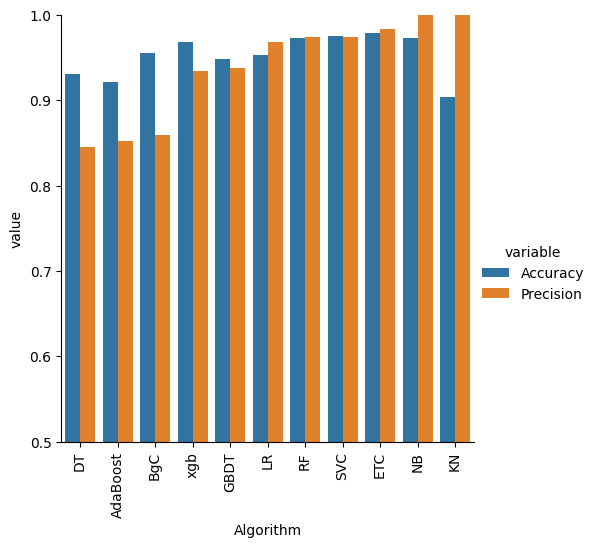

In [ ]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

## 7. Model Improvement

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [ ]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [ ]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars', ascending=True)

In [ ]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,DT,0.931335,0.845361,0.931335,0.845361,0.931335,0.845361,0.931335,0.845361
1,AdaBoost,0.921663,0.851852,0.921663,0.851852,0.921663,0.851852,0.921663,0.851852
2,BgC,0.955513,0.859375,0.955513,0.859375,0.955513,0.859375,0.955513,0.859375
3,xgb,0.968085,0.933884,0.968085,0.933884,0.968085,0.933884,0.968085,0.933884
4,GBDT,0.948743,0.938144,0.948743,0.938144,0.948743,0.938144,0.948743,0.938144
5,LR,0.953578,0.968750,0.953578,0.968750,0.953578,0.968750,0.953578,0.968750
6,RF,0.972921,0.974138,0.972921,0.974138,0.972921,0.974138,0.972921,0.974138
7,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
8,ETC,0.978723,0.983333,0.978723,0.983333,0.978723,0.983333,0.978723,0.983333
9,NB,0.972921,1.000000,0.972921,1.000000,0.972921,1.000000,0.972921,1.000000


In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

In [ ]:
from sklearn.ensemble import VotingClassifier

In [ ]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [ ]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9806576402321083
Precision 0.9916666666666667


In [ ]:
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [ ]:
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

In [ ]:
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(y_test, y_pred))

Accuracy 0.9777562862669246
Precision 0.9323308270676691


In [ ]:
import pickle

In [ ]:
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))